<a target="_blank" href="https://colab.research.google.com/drive/1AgCvD7rFa-3_TvU9dDVgHcH462Ag8_2B?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Smart Pointers in C++

In modernem C++ verwendet man statt rohen Zeigern (`new, delete, malloc, free`) sogenannte Smart Pointer. Sie sind wichtig, um sicheren C++ Code zu schreiben.

- `std::unique_ptr<T>`
- `std::shared_ptr<T>`

Dadurch verhindern sie typische Speicherfehler wie:

- Double Free

- Use After Free

- Memory Leaks

- Vergessenes delete

- Unklare Ownership



## `std::unique_ptr` - exklusiver Besitz


`std::unique_ptr` besitzt ein Objekt **allein**. Es kann nur eine Instanz geben, die diesen Speicher "besitzt".

- Keine Memory leaks - Speicher wird automatisch freigegeben, sobald der `unique_ptr` außer Scope geht
- Kein Double Free - `unique_ptr` kann nicht kopiert werden → es existiert immer genau eine Instanz, die löschen darf
- Kein Use after Free - Beim Löschen wird der interne Pointer automatisch auf `nullptr` gesetzt

Beispiel:

In [ ]:
%%writefile uniquepointer.cpp

#include <memory>
#include <iostream>

int main() {

int* nPtr;
int* sPtr;

if(true) { // Scope fängt hier an

  int* normalPtr = new int;
  *normalPtr = 5;
  nPtr = normalPtr;

  std::unique_ptr<int> smartPtr = std::make_unique<int>();
  *smartPtr = 6;

  sPtr = smartPtr.get(); // Rohpointer aus unique_ptr rausbekommen, sollte nicht genutzt werden, dient nur zum Beispiel

} // Scope hört hier auf -> smartPtr ruft free() von selbst auf
  // normalPtr lebt weiter -> memory leak

  std::cout << "Normaler Pointer: " << *nPtr << std::endl;
  std::cout << "Unique Pointer: " << *sPtr << std::endl;


  return 0;

}

In [ ]:
!g++ uniquepointer.cpp -o uniquepointer
!./uniquepointer

Im gezeigten Beispiel werden in einem inneren Scope zwei verschiedene Arten von dynamisch allozierten Speicher verwendet: ein normaler roher Pointer (`normalPtr`) und ein `std::unique_ptr<int>` namens `smartPtr`.

### Verhalten des normalen Pointers `normalPtr`

`normalPtr` wird mit `new int` angelegt, aber niemals mit `delete` freigegeben.
Dadurch entsteht ein Memory Leak: Der reservierte Speicher bleibt auch nach Verlassen des Scopes im Heap liegen, obwohl er nicht mehr erreichbar ist. Der Pointer `nPtr` zeigt zwar weiterhin auf die Speicheradresse, aber es existiert kein Mechanismus, der diesen Speicher automatisch freigibt.
<br/><br/>
### Verhalten des `unique_ptr`

Der `std::unique_ptr<int> smartPtr` funktioniert komplett anders:

- `unique_ptr` besitzt das Objekt exklusiv.

- Beim Verlassen des Scopes wird automatisch dessen *Destruktor* aufgerufen.

- Dieser führt wiederum `delete` auf das verwaltete Objekt aus.

Dadurch wird der Speicher, den `smartPtr` verwaltet, automatisch und genau einmal freigegeben.

Bei der Programmausgabe sieht man, dass der normale Pointer weiterhin den erwarteten Wert liefert, während der Wert des `unique_ptr`-Pointers zufällig bzw. undefiniert ist – sein Speicher wurde bereits durch den `delete`-Aufruf des `unique_ptr` freigegeben.

Auch das Kopieren von `std::unique_ptr` ist nicht möglich: (wegen exklusiven Besitz)



```
std::unique_ptr<int> a = std::make_unique<int>(10) //unique_ptr von Typ int mit Wert 10

// Versuch, den unique_ptr zu kopieren - funktioniert nicht

std::unique_ptr<int> b = a;         // ❌ Compilerfehler
std::unique_ptr<int> c(a);          // ❌ ebenfalls Compilerfehler

```

Auch das funktioniert nicht:


```
void incPtr(std::unique_ptr<int> ptr) { // Funktionsparameter wird kopiert
  *ptr += 1;
}

int main() {

  std::unique_ptr<int> ptr = std::make_unique<int>(10);
  incPtr(ptr); // ❌ Compilerfehler, da Kopie von unique_ptr gemacht wird
  return 0;

}
```





## `std::shared_ptr` - geteilter Besitz

`std::shared_ptr` ist ein Smart Pointer in C++, der ein dynamisch alloziertes Objekt gemeinsam mit mehreren Besitzern verwaltet. Anders als `std::unique_ptr`, der exklusiven Besitz garantiert, arbeitet `shared_ptr` mit einer Referenzzählung: Jede Kopie erhöht die Anzahl der aktiven Besitzer, und erst wenn der letzte `shared_ptr` das Objekt verlässt oder zerstört wird, wird der verwaltete Speicher automatisch freigegeben. Dadurch eignet sich `shared_ptr` besonders in Situationen, in denen mehrere Teile eines Programms gleichzeitig auf dasselbe Objekt zugreifen müssen, ohne manuell auf die Lebensdauer des Objekts achten zu müssen.

Beispiel:

In [ ]:
%%writefile sharedpointer.cpp

#include <memory>
#include <iostream>

void incPtr(std::shared_ptr<int> ptr) { //Kopie von shared_ptr wird erzeugt

  std::cout << "Pointer use_count in incPtr(): " << ptr.use_count() << std::endl;
  *ptr += 1;

}

int main() {

  std::shared_ptr<int> ptrCopy;

  if(true) {

    std::shared_ptr<int> ptr = std::make_shared<int>(10);
    std::cout << "Pointer use_count initially: " << ptr.use_count() << std::endl;

    incPtr(ptr);
    std::cout << "Pointer use_count after incPtr(): " << ptr.use_count() << std::endl;

    ptrCopy = ptr;
    std::cout << "Pointer use_count after copy(): " << ptr.use_count() << std::endl;

} //ptr wird zerstört, da Scope endet -> use_count sinkt um 1

  std::cout << "Pointer use_count after scope was left: " << ptrCopy.use_count() << std::endl;

  return 0;

}


In [ ]:
!g++ sharedpointer.cpp -o sharedpointer
!./sharedpointer

Der gezeigte Code demonstriert das Verhalten von `std::shared_ptr`, insbesondere wie sich der Referenzzähler `use_count` verändert, wenn Kopien des Zeigers erstellt oder der Gültigkeitsbereich verlassen werden. Nur wenn `use_count` den Wert `0` annimmt, wird der Pointer mit `delete` gelöscht.

## `std::weak_ptr` - kein Besitz

`std::weak_ptr` ist ein nicht-besitzender Smart Pointer.
Er arbeitet zusammen mit `std::shared_ptr`, ohne jedoch dessen Referenzzähler zu erhöhen.

Man benutzt ihn hauptsächlich, um *Zyklische Referenzen* (reference cycles) zu vermeiden.
<br></br>
### Beispiel einer zyklischen Referenz

Eine zyklische Referenz entsteht, wenn zwei oder mehr Objekte sich gegenseitig besitzen – also Smart Pointer in einer „Ringschleife“ aufeinander zeigen.

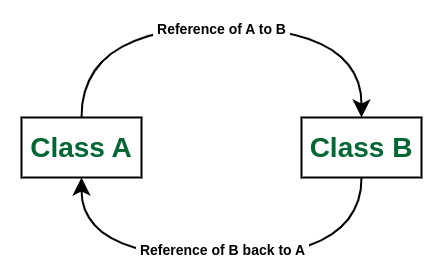


#### Warum ist das ein Problem?

`std::shared_ptr` funktioniert mit Referenzzählung (Reference Counting):

- Jeder shared_ptr erhöht den Zähler für das Objekt

- Wenn der Zähler auf 0 fällt → Speicher wird freigegeben

Das Problem bei einem Zyklus:

```
A hält shared_ptr auf B -> Referenzzähler(B) = 1
B hält shared_ptr auf A -> Referenzzähler(A) = 1
```
Wenn die übergeordneten Objekte verschwinden:

- A wird gelöscht? → Zähler(A) ist 1, weil B es noch hält → wird nicht gelöscht

- B wird gelöscht? → Zähler(B) ist 1, weil A es noch hält → wird nicht gelöscht

Der Referenzzähler fällt nie auf 0 → Speicher wird nicht freigegeben, was zu einem Memory Leak führt.

In [ ]:
%%writefile memoryleak.cpp

#include <iostream>
#include <memory>

class B;

class A {
  public:
  std::shared_ptr<B> b;
  ~A() { std::cout << "A gelöscht\n";}
};

class B {
  public:
  std::shared_ptr<A> a;
  ~B() { std::cout << "B gelöscht\n";}
};

int main() {

  if(true) {

    std::shared_ptr<A> a = std::make_shared<A>();
    std::shared_ptr<B> b = std::make_shared<B>();

    a->b = b;
    b->a = a;

  }

  return 0;

}

In [ ]:
!g++ memoryleak.cpp -o memoryleak
!./memoryleak

Man sieht, dass die Destruktoren `~A()` und `~B()` nie aufgerufen werden, da der Referezenzähler für beide Objekte nie 0 wird.

Lösung mit `weak_ptr`:

In [ ]:
%%writefile weakptr.cpp

#include <iostream>
#include <memory>

class B;

class A {
    public:
    std::shared_ptr<B> b;
    ~A() { std::cout << "A gelöscht\n"; }
};

class B {
    public:
    std::weak_ptr<A> a; // Kein Besitz, Referenzzähler wird nich erhöht.
    ~B() { std::cout << "B gelöscht\n"; }
};

int main() {

    {
        std::shared_ptr<A> a = std::make_shared<A>();
        std::shared_ptr<B> b = std::make_shared<B>();

        a->b = b;
        b->a = a;  // weak_ptr erzeugt keinen Zyklus!
    }

    return 0;

}

In [ ]:
!g++ weakptr.cpp -o weakptr
!./weakptr

### Zugriff auf `weak_ptr`

Der Zugriff erfolgt über die Memberfunktion `lock()`, da der `shared_ptr`, auf dem der `weak_ptr` zeigt, ungültig werden kann (Referenzzähler auf 0 z.B.) und somit auch der `weak_ptr` ungültig wird.

`lock()` liefert:

- einen gültigen `shared_ptr`, falls das Objekt noch existiert

- einen leeren `shared_ptr`, wenn nicht

In [ ]:
%%writefile weakptraccess.cpp

#include <iostream>
#include <memory>

class MyClass{
  public:
  int x = 5;
};

int main() {

  std::shared_ptr<MyClass> sp = std::make_shared<MyClass>();

  std::weak_ptr<MyClass> wp = sp; // weak_ptr auf shared_ptr sp

  if(auto p = wp.lock()) {
    std::cout << p->x << std::endl;
  } else {
    std:: cout << "Objekt existiert nicht mehr\n";
  }

  // Beispiel, wo shared_ptr jetzt ungültig wird:

  std::weak_ptr<MyClass> wp2;

  if(true) {

    std::shared_ptr<MyClass> sp2 = std::make_shared<MyClass>();
    wp2 = sp2;

  } // sp2 wird ungültig nach Verlassen des Scopes, aber weak_ptr wp2 zeigt immer noch drauf

  if(auto p = wp2.lock()) {
    std::cout << p->x << std::endl;
  } else {
    std:: cout << "Objekt existiert nicht mehr\n";
  }

  // Funktion um zu überprüfen, ob der weak_ptr auf ein gültiges Objekt zeigt
  if(wp2.expired()) {
    std::cout << "wp2 ist ungültig geworden.\n";
  }


  return 0;

}

In [ ]:
!g++ weakptraccess.cpp -o weakptraccess
!./weakptraccess

## Übung:

Smart-Pointers funktionieren mit Hilfe von **Konstruktoren und Destruktoren**. In dieser Übung sollen Sie eine Smart-Pointer-Klasse selber erstellen und ihre Funktionsweise austesten. Folgende Aufgaben sind zu erledigen:
<br></br>

- Der Konstruktor soll einen neuen Rohpointer erzeugen und Speicher für den Pointer allokieren
  - Hier soll in der Konsole ausgegeben werden, dass der Pointer erzeugt worden ist

- Der Destruktor soll den allokierten Rohpointer löschen
  - Auch hier soll in der Konsole ausgegeben werden, dass der Pointer gelöscht worden ist
  - Der Rohpointer soll nach dem Löschen auf `nullptr` gesetzt werden

- Alle bekannte Pointer-Operationen (`->` und `*`) sollen wie gewohnt funktionieren (mit Hilfe von **Operator-Overloading**)


In [ ]:
%%writefile uebung.cpp

#include <iostream>

// Testklasse
struct TestClass {
  int a;
};


template<typename T> // Template um Datentyp des Pointers frei zu wählen -> smart_ptr<int>, smart_ptr<double> usw.
class smart_ptr{

private:

  T* rawptr; // Echter Rohpointer

public:


  // Konstruktor
  // TODO:
  // - Speicher mit new allokieren
  // - Konsolenausgabe: "Smart Pointer erzeugt"
  smart_ptr() {

  }

  // Destruktor
  // TODO:
  // - Speicher mit delete freigeben
  // - rawptr auf nullptr setzen
  // - Konsolenausgabe: "Smart Pointer geloescht"
  ~smart_ptr() {

  }


  // Dereferenzierungs-Operator *
  // TODO:
  // - Referenz auf das Objekt zurückgeben
  T& operator*() { }


  // Pfeil-Operator ->
  // TODO:
  // - Rohpointer zurückgeben
  T* operator->() { }


};


int main() {

  std::cout << "Vor dem Scope\n";

  // Hier soll die Funtkion des smart_ptr getestet werden
  if(true) {

      // Smart Pointer erzeugen
      smart_ptr<TestClass> smartPtr;

      // Test: Zugriff über ->
      smartPtr->a = 42;
      std::cout << "Wert von a: " << smartPtr->a << "\n";

      // Test: Zugriff über *
      (*smartPtr).a = 100;
      std::cout << "Neuer Wert von a: " << smartPtr->a << "\n";

  } // Hier muss automatisch der Destruktor aufgerufen werden


  std::cout << "Nach dem Scope\n";


  return 0;

}

In [ ]:
!g++ uebung.cpp -o uebung
!./uebung